# The Anderson impurity model with a discrete bath

The spectral machinery of

> F. B. Kugler, S.-S. B. Lee and J. von Delft,
> *Multipoint Correlation Functions: Spectral Representation and Numerical Evaluation*,
> [Phys. Rev. X **11**, 041006 (2021)](https://doi.org/10.1103/PhysRevX.11.041006)

applied to the model of the paper's Sec. IV: the Anderson impurity model, Eq. (79), with the band replaced by
$N_b\le3$ bath sites so that exact diagonalisation is possible ($4^{N_b+1}$ = 16, 64, 256 states). Nothing
downstream of `spectrum(m)` is new. The PSFs of Eq. (28), the kernels of Eqs. (46), (67b), the PSF-level subtraction
of Eq. (31) and the Keldysh amputation with the Eq. (D2) legs are the ones validated on the atom and the dimer.

$$
H=-\frac U2\sum_\sigma n_{d\sigma}+Un_{d\uparrow}n_{d\downarrow}
+\sum_{n=1}^{N_b}\sum_\sigma\Bigl[\varepsilon_n\,b^\dagger_{n\sigma}b_{n\sigma}
+V_n\bigl(d^\dagger_\sigma b_{n\sigma}+b^\dagger_{n\sigma}d_\sigma\bigr)\Bigr],
\qquad
\Delta(i\nu)=\sum_n\frac{|V_n|^2}{i\nu-\varepsilon_n}.
$$

**Provenance.** The task sheet's closed forms (moment matching, the $N_b=1$ spectrum, the discrete-bath $\chi_0$) and
its reference numbers come from the sheet author's independent Python exact diagonalisation. They are checked here, not
assumed. Paper equations were read from the printed page: Eq. (79), and Eqs. (83)–(84) with "its particle-particle
counterpart yields $-\chi_0$", on p. 16.

| Item | Check | Result |
|:--|:--|:--|
| Sec. 1 | sum rule, $\varepsilon_n\to-\varepsilon_{N_b+1-n}$, anticommutators, $\langle n_{d\sigma}\rangle=\frac12$ | exact / ≤ 1e-13 / ≤ 1e-12 |
| I1 | chain-walk PSFs = dense PSFs, peak by peak | identical to rounding |
| I2 | Dict peak merging = pairwise merging; no straddled cells | identical |
| I3 | `ImpurityModel` interface, `otol` threaded everywhere | existing 58,708 assertions unchanged |
| A1 | $N_b=1$ levels, $Z$, 8 poles, $T\to0$ residues | ≤ 1e-13; 0.172914 / 0.327086 |
| A2 | $G_d(i\pi T)$, 12 reference values | ≤ 4e-14 relative |
| A3 | $U=0$: $[z-\Delta(z)]^{-1}$, MF and KF | MF ≤ 4e-14; KF ≤ 4e-11 on values up to $1/\gamma_0$ |
| B1 | $U=0$ null test, MF and 16 KF components | $S^{\rm con}\le 2\times10^{-15}$, $F\equiv0$ |
| B2 | $V\to0$: $F\to F^{\rm atom}$ | exact at $V=0$; deviation $\propto V^2$ |
| B3 | weak coupling, Eq. (84) with the discrete-bath $\chi_0$ | ≤ 1.3e-5 (3-point Richardson) |
| B4 | crossing, both forms | ≤ 4e-13 |
| B5 | $G^{1111}=0$, $F^{2222}\equiv0$, $F^{[\eta]}$ vs regular Matsubara objects | exact / exact / ≤ 7e-13 |
| B6 | cost of tables and grids, $N_b=1,2$ | see B6 |
| O1 | $\chi_{\rm loc}$ table | all digits |
| O2 | $\delta(\omega_{12})$ term vs $\beta\Delta_{\rm ST}$ | cut off, but at the doublet gap $a-b$, not $\Delta_{\rm ST}$ |
| O3 | heat maps next to the atom's | figures below |

*Running.* The whole notebook takes about 15 minutes with 4 threads (`JULIA_NUM_THREADS=4`); almost all of it is the
$N_b=2$ Keldysh slices. On Colab, upload all of `src/` (now including `aim.jl` and `psf_chain.jl`), keep the folder
layout described in the atom notebook, and `Pkg.add(["StaticArrays", "CairoMakie", "JLD2", "BenchmarkTools"])` first.

In [1]:
include(joinpath(@__DIR__, "..", "src", "HubbardAtom.jl"))
using .HubbardAtom
using LinearAlgebra, Printf, BenchmarkTools, JLD2, CairoMakie
CairoMakie.activate!(type = "png", px_per_unit = 2)
FIGDIR = joinpath(@__DIR__, "figures", "aim"); mkpath(FIGDIR)
imp4(m, ops, s) = (impurity_operators(m, ops, :up)..., impurity_operators(m, ops, s === :updn ? :dn : :up)...)
# the MF vertex from the tables at arbitrary integer Matsubara indices
function Fmf(m, tabs, ms)
    Gc = mf_correlator_point(ms, m.β, tabs.con)
    Gc / (mf_leg(ms[1], m.β, tabs.leg) * mf_leg(-ms[2], m.β, tabs.leg) * mf_leg(ms[3], m.β, tabs.leg) * mf_leg(-ms[4], m.β, tabs.leg))
end
FREQS = [(1, 3, 5, -9), (1, -1, 3, -3), (1, 3, -1, -3), (1, 3, -3, -1), (1, -1, 1, -1), (3, -1, -3, 1), (5, -3, 1, -3)]
@printf("Julia %s, %d thread(s)\n", VERSION, Threads.nthreads())

Julia 1.13.0, 4 thread(s)


## Sec. 1 — model and bath discretisation

Moment matching on a partition $x_0<\dots<x_{N_b}$ of $[-D,D]$ [derived on the sheet]:
$|V_n|^2=\frac{\Delta}{\pi}(x_n-x_{n-1})$, $\varepsilon_n=\frac12(x_{n-1}+x_n)$, so that $\sum_n|V_n|^2=2D\Delta/\pi$ for any
partition. The presets use $D=1$. The logarithmic partition $\{-D,-D/\Lambda,D/\Lambda,D\}$ is available through `box_edges(3; Λ)`,
but every benchmark uses the presets.

The operators come from `jordan_wigner(2(Nb+1))` in mode order $d{\uparrow},d{\downarrow},b_1{\uparrow},b_1{\downarrow},\dots$. The
hybridisation $d^\dagger_\sigma b_{n\sigma}$ crosses every mode in between and gets those string signs from the matrix
products. Degenerate blocks are gauge-fixed with $N+\sqrt2S_z$.

In [2]:
println(" Nb  edges                        ε_n                        |V_n|²·π/Δ      Σ|V|² vs 2DΔ/π")
for Nb in 1:3
    ε, V = discretize_box(0.1, 1.0, box_edges(Nb))
    @printf("  %d  %-28s %-26s %-15s %.2e\n", Nb, string(round.(box_edges(Nb); digits = 3)), string(round.(ε; digits = 3)),
            string(round.(abs2.(V) .* π ./ 0.1; digits = 3)), abs(sum(abs2, V) - 0.2 / π))
end
for Nb in 1:3
    m = aim_model(Nb; U = 1.3, β = 2.0); ops = operators(m); n = size(ops.H, 1); Id = Matrix(1.0I, n, n)
    car = maximum(max(norm(ops.c[a] * ops.c[b]' + ops.c[b]' * ops.c[a] - (a == b) * Id), norm(ops.c[a] * ops.c[b] + ops.c[b] * ops.c[a]))
                  for a in eachindex(ops.c), b in eachindex(ops.c))
    nd = maximum(abs(thermal_average(spectrum(aim_model(Nb; U = 1.3, β = β)), (impurity_operators(m, ops, σ)[2] * impurity_operators(m, ops, σ)[1])) - 0.5)
                 for β in (0.5, 10.0, 100.0), σ in (:up, :dn))
    @printf("Nb=%d: %3d states, %2d modes: max anticommutator deviation %.1e,  max |⟨n_dσ⟩ - ½| over β ∈ {0.5, 10, 100} = %.1e\n",
            Nb, n, length(ops.c), car, nd)
end

 Nb  edges                        ε_n                        |V_n|²·π/Δ      Σ|V|² vs 2DΔ/π


  1  [-1.0, 1.0]                  [0.0]                      [2.0]           0.00e+00
  2  [-1.0, 0.0, 1.0]             [-0.5, 0.5]                [1.0, 1.0]      1.39e-17


  3  [-1.0, -0.333, 0.333, 1.0]   [-0.667, 0.0, 0.667]       [0.667, 0.667, 0.667] 1.39e-17
Nb=1:  16 states,  4 modes: max anticommutator deviation 0.0e+00,  max |⟨n_dσ⟩ - ½| over β ∈ {0.5, 10, 100} = 5.6e-16


Nb=2:  64 states,  6 modes: max anticommutator deviation 0.0e+00,  max |⟨n_dσ⟩ - ½| over β ∈ {0.5, 10, 100} = 5.3e-14
Nb=3: 256 states,  8 modes: max anticommutator deviation 0.0e+00,  max |⟨n_dσ⟩ - ½| over β ∈ {0.5, 10, 100} = 1.0e-15


## I3 — an impurity-model interface

`propagator`, `correlator_4p`, `disconnected_4p`, `connected_4p`, `vertex` and `heatmap_tables` now take any
`m::ImpurityModel` (`HubbardAtomModel`, `AIMModel`). They obtain $d_\sigma$, $d^\dagger_\sigma$ from
`impurity_operators(m, ops, σ)`. Eq. (73) holds unchanged, because $\langle d_\sigma d_{\sigma'}\rangle=0$ by charge conservation.
`propagator_exact`, `vertex_exact` stay atom-only. `otol` now reaches `permuted_psfs` on every path, with a
model-dependent default (`default_otol`: 0 for the atom, `1e-12` for the AIM, where $H$ is not diagonal in the Fock
basis). The existing 58,708 assertions pass unchanged.

## A1 — closed-form spectrum for $N_b=1$ [derived on the sheet]

With the bath site at $\varepsilon=0$, $a\equiv\frac14\sqrt{U^2+64V^2}$ and $b\equiv\frac14\sqrt{U^2+16V^2}$, the levels are
$-U/4-a$ (1, singlet ground state), $-U/4-b$ (4), $-U/2$ (3, triplet), $0$ (3), $-U/4+b$ (4) and $-U/4+a$ (1), with
$Z=3+3e^{\beta U/2}+8e^{\beta U/4}\cosh\beta b+2e^{\beta U/4}\cosh\beta a$. $G_d$ has eight poles, at
$\pm(a+b),\pm(a-b),\pm(U/4+b),\pm(U/4-b)$. They are read off the $\ell=2$ PSFs below.

In [3]:
for (U, β, Δ) in ((2.0, 10.0, 0.1), (0.5, 3.0, 0.1), (3.0, 1.0, 0.4))
    m = aim_model(1; U = U, β = β, Δ = Δ); sp = spectrum(m)
    lev = sort(vcat([fill(e, d) for (e, d) in aim_levels_nb1(m)]...))
    P = propagator_poles(m; sp = sp)
    @printf("(U, β, Δ) = (%.1f, %4.1f, %.1f): levels %.1e, Z %.1e, %d poles, positions %.1e, Σ residues - 1 = %.1e\n", U, β, Δ,
            maximum(abs, sp.E - lev), abs(sp.Z / aim_partition_function_nb1(m) - 1), length(P),
            maximum(abs, [p[1] for p in P] - aim_poles_nb1(m)), sum(p[2] for p in P) - 1)
end
m = aim_model(1; U = 2.0, β = 1000.0)
println("\nT → 0 (β = 1000), (U, Δ, D) = (2, 0.1, 1): residues of G_d")
for (E, r) in propagator_poles(m)
    @printf("   pole %+.6f   residue %.6f\n", E, r)
end
println("sheet: 0.172914 at each of ±(a-b), 0.327086 at each of ±(a+b)")

(U, β, Δ) = (2.0, 10.0, 0.1): levels 1.1e-15, Z 7.1e-15, 8 poles, positions 1.1e-15, Σ residues - 1 = 2.2e-16
(U, β, Δ) = (0.5,  3.0, 0.1): levels 7.8e-16, Z 1.3e-15, 8 poles, positions 6.7e-16, Σ residues - 1 = 2.2e-16


(U, β, Δ) = (3.0,  1.0, 0.4): levels 3.2e-15, Z 0.0e+00, 8 poles, positions 3.0e-15, Σ residues - 1 = 2.2e-16

T → 0 (β = 1000), (U, Δ, D) = (2, 0.1, 1): residues of G_d
   pole -1.270441   residue 0.327086
   pole -1.060055   residue 0.000000
   pole -0.150330   residue 0.172914


   pole -0.060055   residue 0.000000
   pole +0.060055   residue 0.000000
   pole +0.150330   residue 0.172914
   pole +1.060055   residue 0.000000
   pole +1.270441   residue 0.327086
sheet: 0.172914 at each of ±(a-b), 0.327086 at each of ±(a+b)


## A2 — reference values of $G_d(i\pi T)$

$D=1$, $\Delta=0.1$, the presets of Sec. 1. The sheet's values come from its independent Python ED. The target is
$10^{-12}$ relative, with $|{\rm Re}\,G_d|$ at rounding level (particle–hole symmetry). $N_b=3$ runs through the chain walk.

In [4]:
ref = [(1, 0.5, 10, -1.768830080892028), (1, 0.5, 100, -0.485140003453097), (1, 2.0, 10, -0.737281826717041),
       (1, 2.0, 100, -0.473355579919950), (2, 0.5, 10, -2.030691733046821), (2, 0.5, 100, -0.949216078082626),
       (2, 2.0, 10, -0.429277187551225), (2, 2.0, 100, -0.059820038830754), (3, 0.5, 10, -2.000856350026648),
       (3, 0.5, 100, -1.391281201028393), (3, 2.0, 10, -0.513738264064291), (3, 2.0, 100, -1.162698345747195)]
println(" Nb   U     β    Im G_d(iπT)            sheet                  rel. diff   |Re G_d|   PSF method")
for (Nb, U, β, r) in ref
    m = aim_model(Nb; U = U, β = β); sp = spectrum(m)
    G = propagator(m, fermionic_freq(0); sp = sp)
    @printf("  %d  %.1f  %4d   %.15f  %.15f   %.1e    %.1e   %s\n", Nb, U, β, imag(G), r, abs(imag(G) - r) / abs(r), abs(real(G)),
            default_psf_method(sp))
end

 Nb   U     β    Im G_d(iπT)            sheet                  rel. diff   |Re G_d|   PSF method
  1  0.5    10   -1.768830080892031  -1.768830080892028   1.8e-15    1.6e-15   dense
  1  0.5   100   -0.485140003453099  -0.485140003453097   5.0e-15    5.8e-15   dense


  1  2.0    10   -0.737281826717042  -0.737281826717041   1.1e-15    4.2e-17   dense
  1  2.0   100   -0.473355579919952  -0.473355579919950   5.3e-15    7.7e-15   dense
  2  0.5    10   -2.030691733046817  -2.030691733046821   1.7e-15    1.9e-15   chain
  2  0.5   100   -0.949216078082621  -0.949216078082626   4.9e-15    3.9e-14   chain


  2  2.0    10   -0.429277187551225  -0.429277187551225   6.5e-16    1.2e-15   chain
  2  2.0   100   -0.059820038830754  -0.059820038830754   8.1e-16    2.4e-14   chain
  3  0.5    10   -2.000856350026630  -2.000856350026648   9.1e-15    1.8e-14   chain
  3  0.5   100   -1.391281201028346  -1.391281201028393   3.4e-14    1.4e-13   chain


  3  2.0    10   -0.513738264064288  -0.513738264064291   5.0e-15    2.8e-15   chain
  3  2.0   100   -1.162698345747233  -1.162698345747195   3.2e-14    2.3e-14   chain


## A3 — the non-interacting limit

At $U=0$: $G_d(i\nu)=[i\nu-\Delta(i\nu)]^{-1}$ exactly. In the KF, $G^R_d$ from Eq. (67) at finite $\gamma_0$ equals
$[z-\Delta(z)]^{-1}$ at $z=\omega+i\gamma_0$ exactly, since both are the same rational function.

In [5]:
for Nb in 1:3
    m = aim_model(Nb; U = 0.0, β = 10.0); sp = spectrum(m); Os = impurity_operators(m, operators(m), :up)
    emf = maximum(abs(propagator(m, fermionic_freq(k); sp = sp) - propagator_free(m, im * value(fermionic_freq(k), 10.0))) for k in -4:3)
    cache = permuted_psfs(sp, Os; otol = 1e-12)
    ekf = maximum(abs(keldysh_correlator(m, Os, [ω, -ω], [1]; γ0 = γ, sp = sp, cache = cache) - propagator_free(m, ω + im * γ))
                  for ω in (-1.3, -0.4, 0.0, 0.25, 0.9), γ in (0.1, 0.01))
    @printf("Nb=%d: MF, 8 Matsubara points: max |G_d - [iν - Δ(iν)]⁻¹| = %.1e;   KF G^R, 10 points: %.1e\n", Nb, emf, ekf)
end

Nb=1: MF, 8 Matsubara points: max |G_d - [iν - Δ(iν)]⁻¹| = 4.0e-15;   KF G^R, 10 points: 2.2e-12
Nb=2: MF, 8 Matsubara points: max |G_d - [iν - Δ(iν)]⁻¹| = 3.9e-14;   KF G^R, 10 points: 3.9e-11


Nb=3: MF, 8 Matsubara points: max |G_d - [iν - Δ(iν)]⁻¹| = 1.1e-14;   KF G^R, 10 points: 1.3e-13


## I1, I2 — PSFs that scale

The dense `psf` visits all $n^\ell$ eigenstate tuples: $16^4\approx6.6\times10^4$ per permutation for $N_b=1$,
$64^4\approx1.7\times10^7$ for $N_b=2$, and $256^4\approx4.3\times10^9$ for $N_b=3$. Eq. (28) needs only the cycles along
nonzero matrix elements. The chain walk stores each rotated, `otol`-filtered operator as row-wise adjacency lists and
walks $s_1\to s_2\to s_3\to s_4\to s_1$ directly, writing straight into the merged `PSF4` storage (I1). Merging
uses a `Dict` on positions rounded to `TOL_DEG` cells, followed by a neighbour pass that re-joins a peak split across a
cell boundary (I2). The dense `psf` and the pairwise merge are kept as references.

The equality checks first (all 24 permutations, parts `:full` and `:connected`), then the cost table: wall time for all
24 connected tables, surviving cycles of $S$ per permutation, and merged peaks of $S^{\rm con}$ per permutation.

In [6]:
function sametabs(A, B)
    key(x) = round.(x; digits = 9); dw = 0.0
    for (a, b) in zip(A, B)
        (a.p == b.p && length(a.w) == length(b.w)) || return (false, NaN)
        ia, ib = sortperm(key.(a.pos)), sortperm(key.(b.pos))
        all(maximum(abs.(a.pos[x] .- b.pos[y])) ≤ 1e-12 for (x, y) in zip(ia, ib)) || return (false, NaN)
        dw = max(dw, maximum(abs(a.w[x] - b.w[y]) for (x, y) in zip(ia, ib); init = 0.0))
    end
    return (true, dw)
end
at = HubbardAtomModel(2.0, 5.0); ao = operators(at)
dm = HubbardDimerModel(0.7, 2.3, 3.0)
systems = [("atom", spectrum(at), (ao.d_up, ao.dag_up, ao.d_dn, ao.dag_dn), 0.0),
           ("dimer, k = 0000", spectrum(dm), dimer_operators_4p(operators(dm), (0, 0, 0, 0), :updn), 1e-12),
           ("AIM Nb = 1", spectrum(aim_model(1; U = 2.0, β = 10.0)), imp4(aim_model(1; U = 2.0, β = 10.0), operators(aim_model(1; U = 2.0, β = 10.0)), :updn), 1e-12),
           ("AIM Nb = 2", spectrum(aim_model(2; U = 2.0, β = 10.0)), imp4(aim_model(2; U = 2.0, β = 10.0), operators(aim_model(2; U = 2.0, β = 10.0)), :updn), 1e-12)]
println("chain walk vs dense PSF, merged tables, all 24 permutations:")
for (name, sp, Os, otol) in systems, part in (:full, :connected)
    ok, dw = sametabs(psf4_tables(sp, Os; part = part, otol = otol, method = :dense), psf4_tables_chain(sp, Os; part = part, otol = otol)[1])
    @printf("   %-16s %-10s identical peak lists: %s   max |Δw| = %.1e\n", name, part, ok, dw)
end
println("\nDict merge vs pairwise merge on the dense terms:")
for (name, sp, Os, otol) in systems[1:2]
    same = all(merge_peaks(d.terms) == merge_peaks_pairwise(d.terms) for part in (:full, :connected)
               for d in permuted_psfs(sp, Os; part = part, otol = otol))
    @printf("   %-16s identical output (positions, weights, order): %s\n", name, same)
end

chain walk vs dense PSF, merged tables, all 24 permutations:


   atom             full       identical peak lists: true   max |Δw| = 0.0e+00
   atom             connected  identical peak lists: true   max |Δw| = 0.0e+00


   dimer, k = 0000  full       identical peak lists: true   max |Δw| = 0.0e+00
   dimer, k = 0000  connected  identical peak lists: true   max |Δw| = 1.1e-16
   AIM Nb = 1       full       identical peak lists: true   max |Δw| = 0.0e+00
   AIM Nb = 1       connected  identical peak lists: true   max |Δw| = 2.8e-17
   AIM Nb = 2       full       identical peak lists: true   max |Δw| = 0.0e+00
   AIM Nb = 2       connected  identical peak lists: true   max |Δw| = 5.6e-17



Dict merge vs pairwise merge on the dense terms:
   atom             identical output (positions, weights, order): true
   dimer, k = 0000  identical output (positions, weights, order): true


In [7]:
m3 = aim_model(3; U = 2.0, β = 10.0)
push!(systems, ("AIM Nb = 3", spectrum(m3), imp4(m3, operators(m3), :updn), 1e-12))
psf4_tables(systems[1][2], systems[1][3]; method = :dense); psf4_tables_chain(systems[1][2], systems[1][3])   # compile
println(" system           states  dense: 24 tables   chain: 24 tables   cycles of S / permutation   merged peaks of S^con / permutation")
cost = []
for (name, sp, Os, otol) in systems
    n = length(sp.E)
    td = n ≤ 64 ? (@elapsed psf4_tables(sp, Os; part = :connected, otol = otol, method = :dense)) : NaN
    tc = @elapsed ((tabs, st) = psf4_tables_chain(sp, Os; part = :connected, otol = otol))
    push!(cost, (name = name, n = n, dense = td, chain = tc, cycles = extrema(st.cycles), peaks = extrema(st.peaks), total = sum(st.peaks)))
    @printf(" %-16s %5d   %14s   %14s    %8d – %-8d            %8d – %-8d (Σ %d)\n", name, n,
            isnan(td) ? "skipped" : @sprintf("%.3f s", td), @sprintf("%.3f s", tc), st.cycles[1] == 0 ? 0 : minimum(st.cycles), maximum(st.cycles),
            minimum(st.peaks), maximum(st.peaks), sum(st.peaks))
end
println("\n(dense skipped for Nb = 3: 256⁴ ≈ 4.3×10⁹ tuples per permutation)")

 system           states  dense: 24 tables   chain: 24 tables   cycles of S / permutation   merged peaks of S^con / permutation


 atom                 4          0.001 s          0.016 s           1 – 1                          4 – 5        (Σ 104)
 dimer, k = 0000     16          0.018 s          0.000 s           8 – 13                        20 – 21       (Σ 488)


 AIM Nb = 1          16          0.025 s          0.002 s          64 – 100                      110 – 126      (Σ 2896)
 AIM Nb = 2          64          2.830 s          0.147 s        4046 – 5537                    4918 – 5249     (Σ 123068)


 AIM Nb = 3         256          skipped         25.021 s      646304 – 814512                301835 – 346159   (Σ 7915652)

(dense skipped for Nb = 3: 256⁴ ≈ 4.3×10⁹ tuples per permutation)


Up to $N_b=2$ the chain walk and the dense PSF produce the same merged peaks, with weights equal to $10^{-16}$. The
Dict merge reproduces the pairwise one exactly, including the order of the peaks. The chain walk makes $N_b=3$
possible at all: about $0.7$–$0.8\times10^6$ surviving cycles and $3\times10^5$ merged peaks per permutation, in tens of
seconds. The dense sum would enumerate $4.3\times10^9$ tuples per permutation.

## B1 — the $U=0$ null test

$S^{\rm con}\equiv0$ and $F\equiv0$, in the MF and all 16 KF components, both spins, $N_b=1,2$. As for V5 on the atom, this
tests the PSF split of Eq. (31), not the kernel: at $U=0$ every connected peak cancels before any kernel is applied.

In [8]:
for Nb in (1, 2)
    m = aim_model(Nb; U = 0.0, β = 10.0); sp = spectrum(m); ops = operators(m)
    ws = fm = fk = 0.0
    for s in (:updn, :upup)
        T, _ = psf4_tables_chain(sp, imp4(m, ops, s); otol = 1e-12, wtol = 0.0)
        ws = max(ws, maximum(maximum(abs, P.w; init = 0.0) for P in T))
        tm = heatmap_tables(m, s, :MF; sp = sp); tk = heatmap_tables(m, s, :KF; sp = sp)
        fm = max(fm, maximum(abs(Fmf(m, tm, ms)) for ms in FREQS))
        buf = zeros(ComplexF64, 16)
        for (ν, νp, ω) in ((0.3, -0.2, 0.0), (0.0, 0.1, 0.0), (-0.7, 0.5, 0.15))
            vertex_point!(buf, ν, νp, ω, HeatmapParams(0.0, 10.0, 0.1), tk); fk = max(fk, maximum(abs, buf))
        end
    end
    @printf("Nb=%d, U=0: max |S^con weight| before dropping = %.1e;  max |F|: MF %.1e, KF (16 components) %.1e\n", Nb, ws, fm, fk)
end

Nb=1, U=0: max |S^con weight| before dropping = 3.9e-16;  max |F|: MF 0.0e+00, KF (16 components) 0.0e+00
Nb=2, U=0: max |S^con weight| before dropping = 1.7e-15;  max |F|: MF 0.0e+00, KF (16 components) 0.0e+00


## B2 — $V\to0$: the two branches of Eq. (46) again

At $V=0$ the impurity decouples and $F$ must equal Eq. (85) exactly (`vertex_exact`). The bath levels are then
degenerate with impurity levels, so terms take the anomalous branch of Eq. (46). At $V\neq0$ they move to the regular
branch with near-vanishing denominators. $U=2$, $\beta=5$, both spins, seven frequency points including every
$\delta$ channel.

In [9]:
U, β = 2.0, 5.0; atom = HubbardAtomModel(U, β)
B2 = Dict{Int,Vector{Float64}}()
for Nb in (1, 2)
    @printf("Nb = %d (bath levels %s)\n      V        max |F - F^atom|    dev / V²\n", Nb, string(aim_model(Nb; U = U, β = β).ε))
    for V in (0.0, 1e-1, 1e-2, 1e-3)
        m = AIMModel(U, β, aim_model(Nb; U = U, β = β).ε, fill(V, Nb))
        e = maximum(abs(Fmf(m, heatmap_tables(m, s, :MF), ms) - vertex_exact(atom, s, MatsubaraFreq.(collect(ms))))
                    for s in (:updn, :upup), ms in FREQS)
        push!(get!(B2, Nb, Float64[]), e)
        @printf("   %6s   %.3e          %s\n", V == 0 ? "0" : @sprintf("%.0e", V), e, V == 0 ? "" : @sprintf("%.1f", e / V^2))
    end
end
m = AIMModel(U, β, [-0.5, 0.5], [1e-4, 1e-4])
e12 = maximum(abs(Fmf(m, heatmap_tables(m, s, :MF), ms) - vertex_exact(atom, s, MatsubaraFreq.(collect(ms)))) for s in (:updn, :upup), ms in FREQS)
e8 = maximum(abs(Fmf(m, heatmap_tables(m, s, :MF; otol = 1e-8), ms) - vertex_exact(atom, s, MatsubaraFreq.(collect(ms)))) for s in (:updn, :upup), ms in FREQS)
sp = spectrum(m)
@printf("\nNb = 2, V = 1e-4: dev/V² = %.0f with otol = 1e-12, %.1f with otol = 1e-8;  smallest level spacing %.1e\n", e12 / 1e-8, e8 / 1e-8,
        minimum(filter(>(1e-12), diff(sp.E))))

Nb = 1 (bath levels [0.0])
      V        max |F - F^atom|    dev / V²
        0   8.531e-14          


    1e-01   2.584e+01          2583.7
    1e-02   2.942e-01          2942.0


    1e-03   2.946e-03          2946.0
Nb = 2 (bath levels [-0.5, 0.5])
      V        max |F - F^atom|    dev / V²


        0   1.137e-13          
    1e-01   3.070e+01          3069.7


    1e-02   3.591e-01          3591.1
    1e-03   3.596e-03          3595.9



Nb = 2, V = 1e-4: dev/V² = 2440089 with otol = 1e-12, 3590.3 with otol = 1e-8;  smallest level spacing 2.7e-08


At $V=0$ the AIM reproduces Eq. (85) to $10^{-13}$. For $V\neq0$ the deviation follows a clean $V^2$ law down to
$V=10^{-3}$ for both $N_b$, so the regular branch takes over from the anomalous one without a jump.

**Where it breaks.** For $N_b=2$ at $V=10^{-4}$ the $V^2$ law fails by orders of magnitude. The cause is the one seen in
D8 of the dimer. Some levels are split only by $\sim V^2\approx3\times10^{-8}$, so LAPACK mixes the nearly degenerate
eigenvectors at $\varepsilon/{\rm gap}\sim10^{-8}$. Symmetry-forbidden matrix elements of that size pass the `1e-12`
filter and add spurious peaks. With `otol = 1e-8` the $V^2$ law returns exactly. The small-$V$ limit of a model with
split degeneracies needs either an exact treatment of the degeneracy or a filter above $\varepsilon$/gap.

## B3 — weak coupling, Eq. (84)

$F_{\sigma\sigma'}=U\delta_{\sigma,\bar\sigma'}-U^2[\delta_{\sigma,\sigma'}\chi_0(i\omega_{12})+\delta_{\sigma,\bar\sigma'}\chi_0(i\omega_{13})-\chi_0(i\omega_{14})]$
(p. 16), with the discrete-bath bubble [derived on the sheet]
$\chi_0(i\omega_m)=-\sum_{a,b}r_ar_b\,[n_F(e_a)-n_F(e_b)]/(i\omega_m+e_a-e_b)$, or $+\beta\,n_F(e_a)(1-n_F(e_a))$ at $m=0$, $e_a=e_b$.
Here $G_0=[i\nu-\Delta(i\nu)]^{-1}=\sum_ar_a/(i\nu-e_a)$ is the particle–hole symmetric, Hartree-shifted propagator, i.e. the
$U=0$ propagator of this very code. The bubble first against the sheet's brute Matsubara sum, then
$\lim_{U\to0}(F-U\delta_{\sigma\bar\sigma'})/U^2$. That limit comes from a three-point Richardson extrapolation from
$U=10^{-2},\frac12\cdot10^{-2},\frac14\cdot10^{-2}$, which removes the $O(U)$ and $O(U^2)$ corrections; the two-point
version of D7 leaves $O(U^2)$ at the $10^{-4}$ level. $\beta=10$, 20 frequency triples including points with
$\omega_{12}=0$, $\omega_{13}=0$, $\omega_{14}=0$.

In [10]:
m2 = aim_model(2; U = 0.0, β = 10.0)
@printf("χ₀, Nb = 2, β = 10:  χ₀(0) = %.6f   χ₀(iω₁) = %.6f   χ₀(iω₃) = %.6f     sheet: 1.893894, 0.140828, 0.028022\n",
        real(chi0_bubble(m2, 0)), real(chi0_bubble(m2, 2)), real(chi0_bubble(m2, 6)))
F20 = vcat(FREQS, [(2a + 1, 2b + 1, 2c + 1, -(2a + 2b + 2c + 3)) for (a, b, c) in ((0, 1, -2), (2, -3, 1), (-1, -1, 4), (3, 0, -2), (1, 2, 2),
          (-2, 1, 0), (0, -4, 3), (4, -1, -1), (-3, 2, 2), (1, -2, -1), (2, 2, -5), (-1, 3, -3), (5, -2, 1))])
β = 10.0; Us = (1e-2, 5e-3, 2.5e-3)
for Nb in (1, 2)
    worst = 0.0; worst2 = 0.0; big = 0.0
    for s in (:updn, :upup)
        tabs = [heatmap_tables(aim_model(Nb; U = U, β = β), s, :MF) for U in Us]
        m1 = aim_model(Nb; U = 1.0, β = β)
        for ms in F20
            f = [(Fmf(aim_model(Nb; U = U, β = β), t, ms) - (s === :updn ? U : 0.0)) / U^2 for (t, U) in zip(tabs, Us)]
            br = vertex_second_order(m1, s, ms) - (s === :updn ? 1.0 : 0.0)
            worst = max(worst, abs((8f[3] - 6f[2] + f[1]) / 3 - br)); worst2 = max(worst2, abs(2f[2] - f[1] - br)); big = max(big, abs(br))
        end
    end
    @printf("Nb=%d: max |lim (F - Uδ)/U² - Eq. (84) bracket|, 20 points × 2 spins:  3-point %.1e,  2-point %.1e   (max |bracket| = %.2f)\n",
            Nb, worst, worst2, big)
end

χ₀, Nb = 2, β = 10:  χ₀(0) = 1.893894   χ₀(iω₁) = 0.140828   χ₀(iω₃) = 0.028022     sheet: 1.893894, 0.140828, 0.028022
Nb=1: max |lim (F - Uδ)/U² - Eq. (84) bracket|, 20 points × 2 spins:  3-point 8.7e-08,  2-point 3.2e-05   (max |bracket| = 1.18)


Nb=2: max |lim (F - Uδ)/U² - Eq. (84) bracket|, 20 points × 2 spins:  3-point 1.3e-05,  2-point 2.3e-04   (max |bracket| = 1.89)


## B4, B5 — crossing and the Keldysh vertex

**B4.** $F_{\uparrow\uparrow}(i\boldsymbol\omega)=F_{\uparrow\downarrow}(i\boldsymbol\omega)-F_{\uparrow\downarrow}(i\boldsymbol\omega')$, with $\omega_1\leftrightarrow\omega_3$ and with $\omega_2\leftrightarrow\omega_4$.

**B5.** $G^{1111}=0$ and $F^{2222}\equiv0$ (p. 15, a general consequence of $G^{11}=0$). There is no closed form for the
fully retarded vertex, so H4 is generalised: the left side of
$2F^{[\eta]}(\boldsymbol\omega)=\tilde G(\boldsymbol z)/[\tilde G(z_1)\tilde G(-z_2)\tilde G(z_3)\tilde G(-z_4)]$, $\boldsymbol z=\boldsymbol\omega^{[\eta]}$, uses Eq. (67), the (D2) legs and
Eq. (76). The right side uses only `regular_sum` (4p and 2p), the regular Matsubara kernel at complex frequencies. Since the
MF disconnected part is purely anomalous, $\tilde G^{\rm con}=\tilde G$ as rational functions [derived on the sheet].

**Trap 1.** $F^{[\eta]}_{\uparrow\uparrow}\equiv0$ holds for the atom only, whose $F_{\uparrow\uparrow}$ is purely anomalous (Eq. 85b). The AIM's has a regular part
already at $O(U^2)$, so its retarded components do not vanish.

In [11]:
for Nb in (1, 2)
    m = aim_model(Nb; U = 2.0, β = 5.0); sp = spectrum(m); ops = operators(m)
    tud = heatmap_tables(m, :updn, :MF; sp = sp); tuu = heatmap_tables(m, :upup, :MF; sp = sp)
    c13 = maximum(abs(Fmf(m, tuu, ms) - (Fmf(m, tud, ms) - Fmf(m, tud, (ms[3], ms[2], ms[1], ms[4])))) for ms in FREQS)
    c24 = maximum(abs(Fmf(m, tuu, ms) - (Fmf(m, tud, ms) - Fmf(m, tud, (ms[1], ms[4], ms[3], ms[2])))) for ms in FREQS)
    γ0 = 0.1; prm = HeatmapParams(2.0, 5.0, γ0)
    du, duu = impurity_operators(m, ops, :up)
    leg2 = permuted_psfs(sp, (du, duu); otol = 1e-12)
    Gt(x) = regular_sum(sp, (du, duu), [x, -x]; cache = leg2)
    buf = zeros(ComplexF64, 16); g = zeros(ComplexF64, 16)
    g1111 = f2222 = rel = 0.0; ret_uu = 0.0
    for s in (:updn, :upup)
        Os = imp4(m, ops, s); full = permuted_psfs(sp, Os; otol = 1e-12)
        tfull = heatmap_tables(m, s, :KF; sp = sp, part = :full); tcon = heatmap_tables(m, s, :KF; sp = sp)
        for (ν, νp, ω) in ((0.3, -0.2, 0.0), (0.0, 0.1, 0.0), (-0.7, 0.5, 0.15), (0.45, 0.45, -0.3))
            kf_correlator_point!(g, ph_frequencies(ν, νp, ω), γ0, tfull.con); g1111 = max(g1111, abs(g[1]))
            vertex_point!(buf, ν, νp, ω, prm, tcon); f2222 = max(f2222, abs(buf[16]) / maximum(abs, buf))
            w = collect(ph_frequencies(ν, νp, ω))
            for η in 1:4
                z = omega_eta(w, η, γ0)
                rhs = regular_sum(sp, Os, z; cache = full) / (Gt(z[1]) * Gt(-z[2]) * Gt(z[3]) * Gt(-z[4]))
                c = LinearIndices((2, 2, 2, 2))[ntuple(i -> i == η ? 1 : 2, 4)...]
                rel = max(rel, abs(2buf[c] - rhs) / abs(rhs))
                s === :upup && (ret_uu = max(ret_uu, abs(buf[c])))
            end
        end
    end
    @printf("Nb=%d:  B4 crossing ω₁↔ω₃ %.1e, ω₂↔ω₄ %.1e  |  B5 |G^1111| = %.0e, |F^2222|/max|F| = %.0e, F^[η] vs regular sums: %.1e relative,  max|F^[η]_↑↑| = %.1f\n",
            Nb, c13, c24, g1111, f2222, rel, ret_uu)
end

Nb=1:  B4 crossing ω₁↔ω₃ 1.1e-14, ω₂↔ω₄ 1.4e-14  |  B5 |G^1111| = 0e+00, |F^2222|/max|F| = 0e+00, F^[η] vs regular sums: 7.2e-15 relative,  max|F^[η]_↑↑| = 117.8
Nb=2:  B4 crossing ω₁↔ω₃ 3.7e-13, ω₂↔ω₄ 3.8e-13  |  B5 |G^1111| = 0e+00, |F^2222|/max|F| = 0e+00, F^[η] vs regular sums: 7.0e-13 relative,  max|F^[η]_↑↑| = 45.4


## B6 — cost

The production setting of the heat maps: $U=1$, $T=U/50$, $\gamma_0=T$, $\Delta=0.1$. Timed here: building the four
tables (MF and KF, both spins), and the warm time of one MF $48\times48$ and one KF $401\times401$ slice (↑↓, all 16
components), with the merged peaks per permutation that set the cost per point. The warm time is a second call, after
the first has compiled everything. The KF slices are reused in O3.

In [12]:
HU, HT = 1.0, 1 / 50; hprm = HeatmapParams(HU, 1 / HT, HT)
msg = [2n + 1 for n in -24:23]; νkf = collect(range(-1, 1; length = 401))
KFstore = Dict{Any,Array{ComplexF64,6}}()
B6 = []
for Nb in (1, 2)
    m = aim_model(Nb; U = HU, β = 1 / HT, Δ = 0.1); sp = spectrum(m)
    ttab = @elapsed (tm = heatmap_tables(m, :updn, :MF; sp = sp); tk = heatmap_tables(m, :updn, :KF; sp = sp);
                     heatmap_tables(m, :upup, :MF; sp = sp); heatmap_tables(m, :upup, :KF; sp = sp))
    vertex_grid(msg, msg, 0, hprm, tm); tmf = @elapsed vertex_grid(msg, msg, 0, hprm, tm)
    tkf1 = @elapsed vertex_grid(νkf, νkf, 0.0, hprm, tk)
    tkf2 = @elapsed (KFstore[(Nb, 0.1, :updn)] = vertex_grid(νkf, νkf, 0.0, hprm, tk))
    pk = [length(P.w) for P in tm.con]
    push!(B6, (Nb = Nb, tables = ttab, mf = tmf, kf1 = tkf1, kf2 = tkf2, peaks = extrema(pk), total = sum(pk)))
    @printf("Nb=%d: 4 tables %.2f s | merged peaks/permutation %d–%d (Σ %d) | MF 48² warm %.3f s | KF 401²×16 first %.1f s, warm %.1f s  (%d threads)\n",
            Nb, ttab, extrema(pk)..., sum(pk), tmf, tkf1, tkf2, Threads.nthreads())
end
println("atom, for comparison (heat-map section of the atom notebook): KF 401²×16 warm 2.2 s on one thread, 84 merged peaks in total")

Nb=1: 4 tables 0.14 s | merged peaks/permutation 53–73 (Σ 1556) | MF 48² warm 0.032 s | KF 401²×16 first 9.0 s, warm 9.1 s  (4 threads)


Nb=2: 4 tables 0.58 s | merged peaks/permutation 630–744 (Σ 16364) | MF 48² warm 0.315 s | KF 401²×16 first 94.1 s, warm 101.2 s  (4 threads)
atom, for comparison (heat-map section of the atom notebook): KF 401²×16 warm 2.2 s on one thread, 84 merged peaks in total


## O1 — moment screening in the local susceptibility

$\chi_{\rm loc}=\int_0^\beta d\tau\,\langle S^z_d(\tau)S^z_d\rangle$ is minus the bosonic $\ell=2$ correlator of Eq. (39) at $\omega=0$. The Curie term of
degenerate states comes out of the anomalous branch of Eq. (46). $N_b=1$, $U=2$, $\Delta=0.1$, $\Delta_{\rm ST}=0.2104$. The
sheet's values are given for comparison.

In [13]:
sheet = [(1.0, 0.18048, 0.18276), (10.0, 1.95387, 2.49989), (30.0, 2.23440, 7.5), (100.0, 2.02469, 25.0), (1000.0, 2.02467, 250.0)]
println("     β      χ_loc AIM (Nb=1)   sheet       χ_loc atom   sheet")
for (β, a, t) in sheet
    @printf("  %6.0f      %.5f          %.5f     %9.5f   %9.5f\n", β, local_susceptibility(aim_model(1; U = 2.0, β = β)), a,
            local_susceptibility(HubbardAtomModel(2.0, β)), t)
end
println("\nthe parity of Nb decides screening (U = 1, Δ = 0.1): half filling holds Nb + 1 electrons")
for Nb in 1:3
    m = aim_model(Nb; U = 1.0, β = 50.0); sp = spectrum(m)
    g = count(e -> e - sp.E[1] < 1e-9, sp.E)
    @printf("   Nb=%d: %d electrons, ground-state degeneracy %d;  χ_loc at β = 50, 500: %.3f, %.3f\n", Nb, Nb + 1, g,
            local_susceptibility(m), local_susceptibility(aim_model(Nb; U = 1.0, β = 500.0)))
end

     β      χ_loc AIM (Nb=1)   sheet       χ_loc atom   sheet


       1      0.18048          0.18048       0.18276     0.18276
      10      1.95387          1.95387       2.49989     2.49989


      30      2.23440          2.23440       7.50000     7.50000
     100      2.02469          2.02469      25.00000    25.00000
    1000      2.02467          2.02467     250.00000   250.00000

the parity of Nb decides screening (U = 1, Δ = 0.1): half filling holds Nb + 1 electrons
   Nb=1: 2 electrons, ground-state degeneracy 1;  χ_loc at β = 50, 500: 1.154, 1.153


   Nb=2: 3 electrons, ground-state degeneracy 2;  χ_loc at β = 50, 500: 10.839, 108.010
   Nb=3: 4 electrons, ground-state degeneracy 1;  χ_loc at β = 50, 500: 2.964, 2.725


The table is reproduced to all digits. The atom's free moment gives a Curie law, $\chi\to\beta/4$. With one bath site
the moment is bound into a singlet and $\chi_{\rm loc}$ saturates at about 2.02 once $\beta\Delta_{\rm ST}\gg1$.

One point the task sheet does not make: this depends on the **parity of $N_b$**. At half filling the system holds $N_b+1$
electrons. For $N_b=1,3$ the number is even, the ground state is a singlet and $\chi_{\rm loc}$ saturates. For $N_b=2$ it is
odd, the ground state is a Kramers doublet, and $\chi_{\rm loc}\propto\beta$ keeps growing at any coupling. A finite
discrete bath screens the moment only for odd $N_b$; `singlet_triplet_gap` refuses even $N_b$ for that reason.

## O2 — the $\delta(\omega_{12})$ term against $\beta\Delta_{\rm ST}$

The analysis of D11, repeated for the $N_b=1$ AIM at three couplings, $\Delta=0.1,0.03,0.01$ ($U=2$). The quantity is
`delta_part`: the anomalous term of Eq. (45) in the $\omega_{12}$ channel, on the connected PSF, amputated like the vertex,
at $\boldsymbol\omega=(\nu_0,-\nu_0,\nu_1,-\nu_1)$. It is shown relative to the atom's free-moment value
$\beta u^2\,{\rm th}\prod(i\omega+u)/\prod(i\omega)$ at the same $\beta$. A point is dropped when the connected anomalous term is below
$10^{-13}$ of the full one, i.e. at the roundoff floor.

In [14]:
U = 2.0; msO = MatsubaraFreq.([1, -1, 3, -3])
O2 = Dict{Float64,Any}()
for Δ in (0.1, 0.03, 0.01)
    m1 = aim_model(1; U = U, β = 1.0, Δ = Δ); gap = singlet_triplet_gap_nb1(m1)
    a, b = sqrt(U^2 + 64m1.V[1]^2) / 4, sqrt(U^2 + 16m1.V[1]^2) / 4
    rows = []
    for x in vcat(10 .^ range(-2, 0; length = 9)[1:end-1], 1.0:1.0:34.0)
        β = x / gap; m = aim_model(1; U = U, β = β, Δ = Δ); sp = spectrum(m); ops = operators(m)
        Os = imp4(m, ops, :updn)
        ac = abs(anomalous_part(m, Os, msO; channel = [1, 2], sp = sp, part = :connected, otol = 1e-12))
        af = abs(anomalous_part(m, Os, msO; channel = [1, 2], sp = sp, part = :full, otol = 1e-12))
        D = delta_part(m, :updn, msO; sp = sp, ops = ops)
        u = U / 2; iω = [im * value(f, β) for f in msO]
        free = abs(β * u^2 * tanh(β * u / 2) * prod(iω .+ u) / prod(iω))
        push!(rows, (x = x, β = β, D = real(D), R = abs(D) / free, ok = ac > 1e-13 * af))
    end
    O2[Δ] = (gap = gap, dgap = a - b, rows = rows)
    r = rows
    lr = [(r[i].x + r[i+1].x) / 2 => -(log(abs(r[i+1].D)) - log(abs(r[i].D))) / (r[i+1].β - r[i].β) / gap
          for i in eachindex(r)[1:end-1] if r[i].x ≥ 3 && r[i+1].x ≤ 15]
    sc = findfirst(i -> r[i].ok && r[i+1].ok && sign(r[i].D) != sign(r[i+1].D), eachindex(r)[1:end-1])
    @printf("Δ=%.2f: Δ_ST = %.4f, doublet gap a-b = %.4f = %.3f Δ_ST;  R at x = 0.01: %.3f;  local rate / Δ_ST at x = 3…15: %s;  D changes sign at x ≈ %.1f\n",
            Δ, gap, a - b, (a - b) / gap, r[1].R, join([@sprintf("%.2f", v) for (_, v) in lr], " "), sc === nothing ? NaN : (r[sc].x + r[sc+1].x) / 2)
end
jldsave(joinpath(FIGDIR, "o2_delta_part.jld2"); O2 = Dict(string(k) => (gap = v.gap, dgap = v.dgap, x = [r.x for r in v.rows], beta = [r.β for r in v.rows],
        D = [r.D for r in v.rows], R = [r.R for r in v.rows], ok = [r.ok for r in v.rows]) for (k, v) in O2))

Δ=0.10: Δ_ST = 0.2104, doublet gap a-b = 0.1503 = 0.715 Δ_ST;  R at x = 0.01: 0.750;  local rate / Δ_ST at x = 3…15: 0.74 0.78 0.76 0.75 0.74 0.74 0.74 0.74 0.75 0.76 0.76 0.77;  D changes sign at x ≈ 24.5
Δ=0.03: Δ_ST = 0.0713, doublet gap a-b = 0.0526 = 0.737 Δ_ST;  R at x = 0.01: 0.750;  local rate / Δ_ST at x = 3…15: 1.07 0.95 0.86 0.80 0.78 0.76 0.76 0.76 0.76 0.76 0.77 0.78;  D changes sign at x ≈ 26.5


Δ=0.01: Δ_ST = 0.0248, doublet gap a-b = 0.0185 = 0.745 Δ_ST;  R at x = 0.01: 0.750;  local rate / Δ_ST at x = 3…15: 1.28 1.04 0.90 0.83 0.79 0.77 0.77 0.76 0.76 0.77 0.77 0.78;  D changes sign at x ≈ 26.5


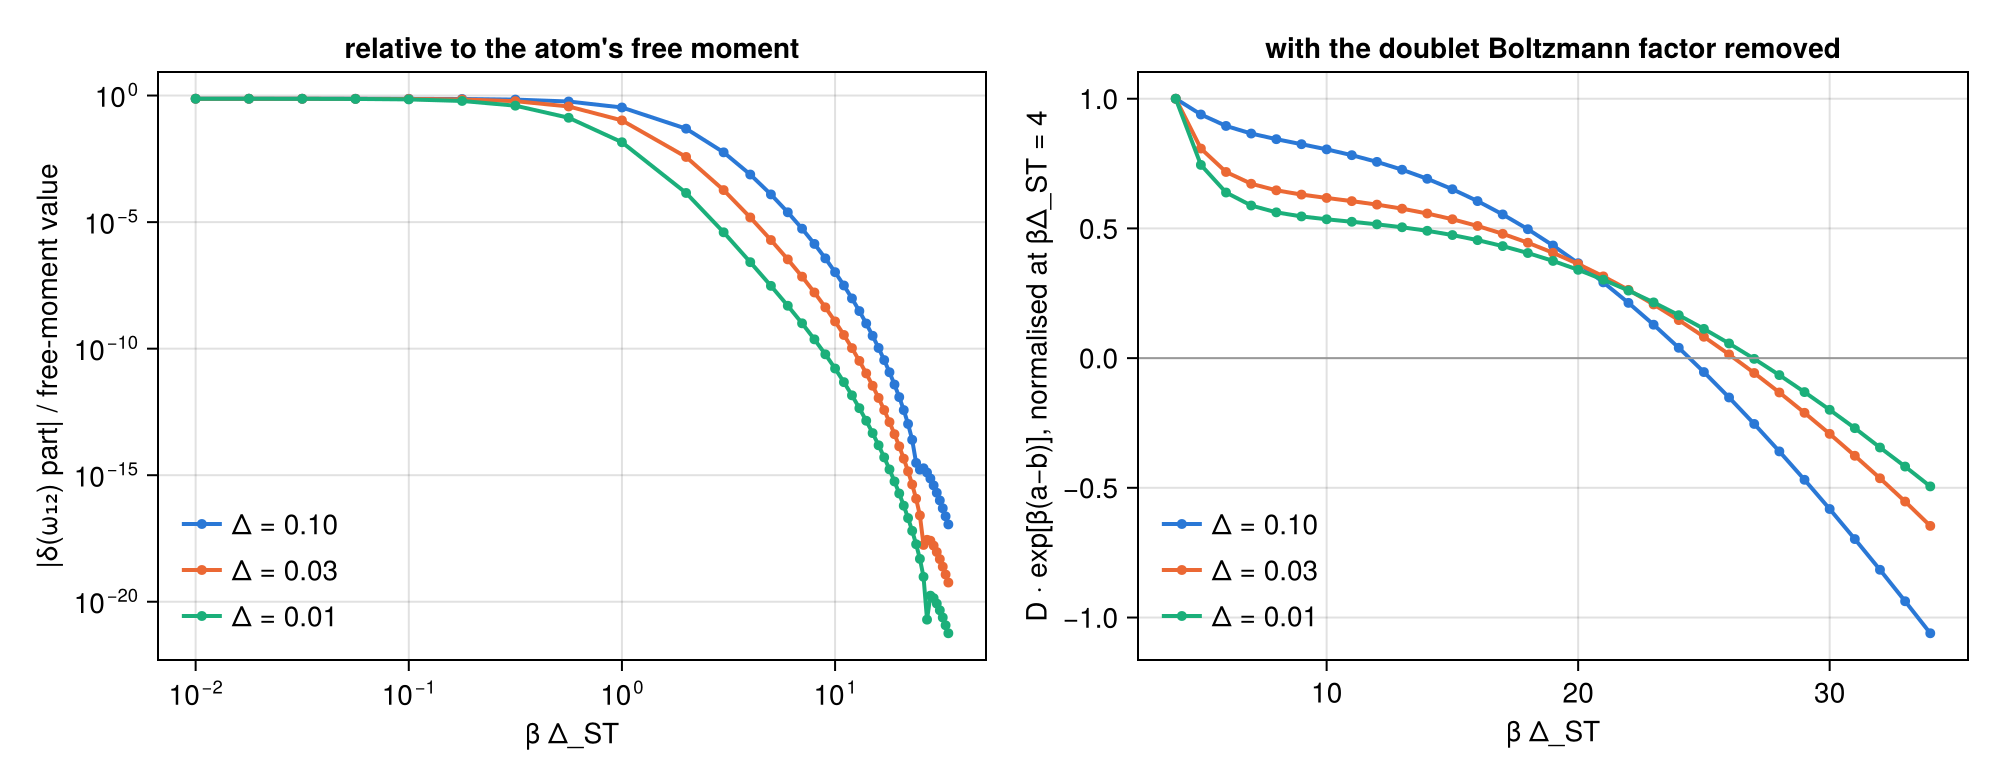

In [15]:
palette = Dict(0.1 => "#2a78d6", 0.03 => "#eb6834", 0.01 => "#1baf7a")
fig = Figure(size = (1000, 390))
ax1 = Axis(fig[1, 1]; xscale = log10, yscale = log10, xlabel = "β Δ_ST", ylabel = "|δ(ω₁₂) part| / free-moment value",
           title = "relative to the atom's free moment")
ax2 = Axis(fig[1, 2]; xlabel = "β Δ_ST", title = "with the doublet Boltzmann factor removed")
for Δ in (0.1, 0.03, 0.01)
    r = [x for x in O2[Δ].rows if x.ok]
    lab = @sprintf("Δ = %.2f", Δ)
    scatterlines!(ax1, [x.x for x in r], [x.R for x in r]; color = palette[Δ], markersize = 7, linewidth = 2, label = lab)
    rr = [x for x in r if x.x ≥ 4]
    scatterlines!(ax2, [x.x for x in rr], [x.D * exp(x.β * O2[Δ].dgap) / abs(rr[1].D * exp(rr[1].β * O2[Δ].dgap)) for x in rr];
                  color = palette[Δ], markersize = 7, linewidth = 2, label = lab)
end
hlines!(ax2, [0.0]; color = :gray60, linewidth = 1)
axislegend(ax1; position = :lb, framevisible = false); axislegend(ax2; position = :lb, framevisible = false)
ax2.ylabel = "D · exp[β(a−b)], normalised at βΔ_ST = 4"
resize_to_layout!(fig)
save(joinpath(FIGDIR, "o2_delta_part.png"), fig; px_per_unit = 2); save(joinpath(FIGDIR, "o2_delta_part.pdf"), fig)
fig

**Reading O2.** The cut-off is there, but the dimer's law does not carry over.

* **High temperature.** For $\beta\Delta_{\rm ST}\ll1$ the $\delta(\omega_{12})$ term is $0.75$ of the atom's free-moment value, not 1:
  the bath site takes part in the thermal ensemble.
* **Crossover.** It sits at $\beta\Delta_{\rm ST}\approx1$, as in the dimer.
* **Beyond it, the decay is not set by $\Delta_{\rm ST}$.** For $\beta\Delta_{\rm ST}\approx6$–15 the local rate $-d\ln|D|/d\beta$ is 0.74–0.78 $\Delta_{\rm ST}$
  for all three couplings. That is the **doublet gap** $a-b$, with $(a-b)/\Delta_{\rm ST}=0.715,\,0.737,\,0.745$. For the $N_b=1$ AIM the
  lowest excitation above the singlet is the four-fold odd-charge level $-U/4-b$ (A1), which lies *below* the triplet.
  Degenerate doublets carry a Curie-like $\beta\delta_\omega$ term too. In the dimer the triplet was the lowest excitation.
* **A sign change.** Near $\beta\Delta_{\rm ST}\approx24.5$–26.5 the term changes sign. With $e^{-\beta(a-b)}$ divided out (right panel), what
  remains is a slowly varying prefactor that crosses zero: two thermally excited contributions of opposite sign, from
  the doublets and the triplet. Near the node the local rate climbs toward $\Delta_{\rm ST}$, which is why a naive
  two-point rate between $\beta\Delta_{\rm ST}=19$ and 40 would suggest "the same law as the dimer".

So the answer to the task's question: exponential cut-off, yes; $\propto\beta e^{-\beta\Delta_{\rm ST}}$, no. The rate is the lowest
excitation that is degenerate, here $a-b$. This is an observation from the numerics, not a derivation.

## O3 — heat maps next to the atom's

P1 (MF, Fig. 10 conventions) and P2 (KF, Fig. 11 conventions) at $U=1$, $T=U/50$, $\gamma_0=T$, $\omega=0$. The rows are:

1. the atom;
2. $N_b=1$ at $\Delta=4\times10^{-4}$ ($\beta\Delta_{\rm ST}=0.10$, moment effectively free);
3. $N_b=1$ at $\Delta=0.1$ ($\beta\Delta_{\rm ST}=15.7$, moment screened);
4. $N_b=2$ at the same two couplings.

For $N_b=2$ there is no singlet–triplet regime (O1: odd electron number, Kramers-doublet ground state), so it is shown at
the two couplings as they are. Colour scales, normalisations and `symlog` thresholds are those of the atom's figures.

In [16]:
cases = [("atom", HubbardAtomModel(HU, 1 / HT)), ("Nb=1, Δ=4e-4", aim_model(1; U = HU, β = 1 / HT, Δ = 4e-4)),
         ("Nb=1, Δ=0.1", aim_model(1; U = HU, β = 1 / HT, Δ = 0.1)), ("Nb=2, Δ=4e-4", aim_model(2; U = HU, β = 1 / HT, Δ = 4e-4)),
         ("Nb=2, Δ=0.1", aim_model(2; U = HU, β = 1 / HT, Δ = 0.1))]
for (lab, m) in cases[2:end]
    g = try; @sprintf("βΔ_ST = %.2f", singlet_triplet_gap(m) / HT); catch; "doublet ground state"; end
    @printf("%-14s V = %s   %s\n", lab, string(round.(m.V; sigdigits = 3)), g)
end
supers(e) = replace(string(e), "-" => "⁻", "0" => "⁰", "1" => "¹", "2" => "²", "3" => "³", "4" => "⁴", "5" => "⁵", "6" => "⁶", "7" => "⁷", "8" => "⁸", "9" => "⁹")
function symlog_ticks(lt, decades)
    vals = vcat([-(10.0^d) for d in decades], 0.0, [10.0^d for d in reverse(decades)])
    (symlog.(vals, lt), [v == 0 ? "0" : (v < 0 ? "−" : "") * "10" * supers(round(Int, log10(abs(v)))) for v in vals])
end
RDBU = Reverse(:RdBu)
nothing

Nb=1, Δ=4e-4   V = [0.016]   βΔ_ST = 0.10
Nb=1, Δ=0.1    V = [0.252]   βΔ_ST = 15.66


Nb=2, Δ=4e-4   V = [0.0113, 0.0113]   doublet ground state
Nb=2, Δ=0.1    V = [0.178, 0.178]   doublet ground state


normalised maxima of |F - F₀| (↑↓):  atom 9.51e-01,  Nb=1, Δ=4e-4 4.76e-01,  Nb=1, Δ=0.1 2.17e-05,  Nb=2, Δ=4e-4 9.41e-01,  Nb=2, Δ=0.1 9.76e-02


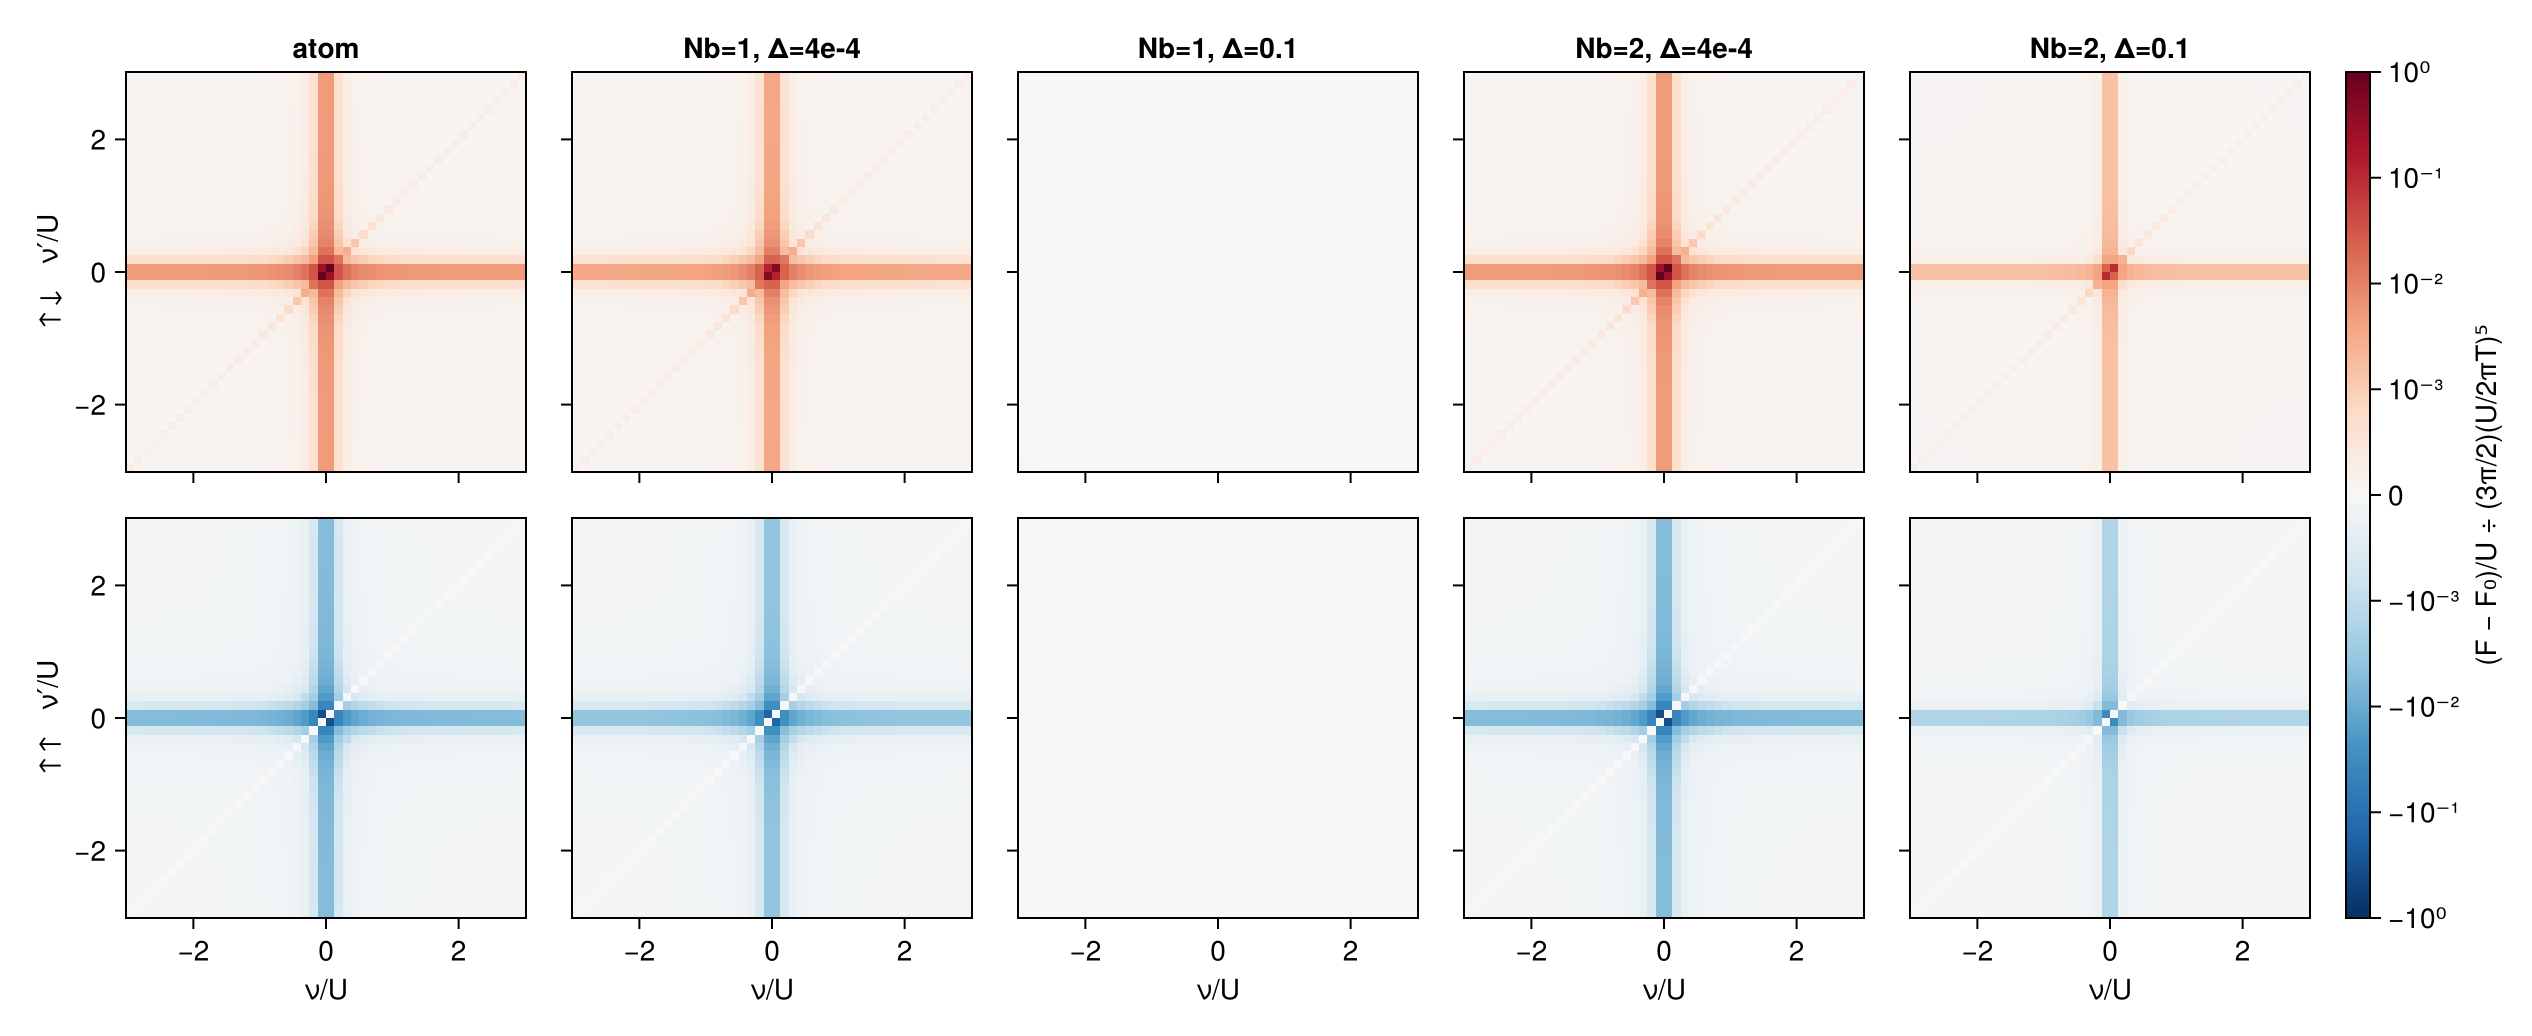

In [17]:
νmf = msg .* π .* HT ./ HU; normmf = 3π / 2 * (HU / (2π * HT))^5
P1 = Dict{Any,Matrix{Float64}}()
for (lab, m) in cases, s in (:updn, :upup)
    F = vertex_grid(msg, msg, 0, hprm, heatmap_tables(m, s, :MF))
    P1[(lab, s)] = real.(F .- (s === :updn ? HU : 0.0)) ./ HU ./ normmf
end
fig = Figure(size = (1300, 560))
for (c, (lab, _)) in enumerate(cases), (r, s) in enumerate((:updn, :upup))
    ax = Axis(fig[r, c]; title = r == 1 ? lab : "", aspect = 1, width = 200, height = 200,
              xlabel = r == 2 ? "ν/U" : "", ylabel = c == 1 ? (s === :updn ? "↑↓   ν′/U" : "↑↑   ν′/U") : "")
    heatmap!(ax, νmf, νmf, symlog.(P1[(lab, s)], 1e-3); colormap = RDBU, colorrange = (-1, 1), rasterize = 2)
    c > 1 && hideydecorations!(ax; grid = false, ticks = false); r == 1 && hidexdecorations!(ax; grid = false, ticks = false)
end
Colorbar(fig[1:2, 6]; colormap = RDBU, limits = (-1, 1), ticks = symlog_ticks(1e-3, 0:-1:-3), label = "(F − F₀)/U ÷ (3π/2)(U/2πT)⁵")
resize_to_layout!(fig)
save(joinpath(FIGDIR, "o3_p1_mf.png"), fig; px_per_unit = 2); save(joinpath(FIGDIR, "o3_p1_mf.pdf"), fig)
jldsave(joinpath(FIGDIR, "o3_p1_mf.jld2"); nu = νmf, maps = Dict(string(k) => v for (k, v) in P1))
@printf("normalised maxima of |F - F₀| (↑↓):  %s\n", join([@sprintf("%s %.2e", lab, maximum(abs, P1[(lab, :updn)])) for (lab, _) in cases], ",  "))
fig

KF slices for O3: 322 s


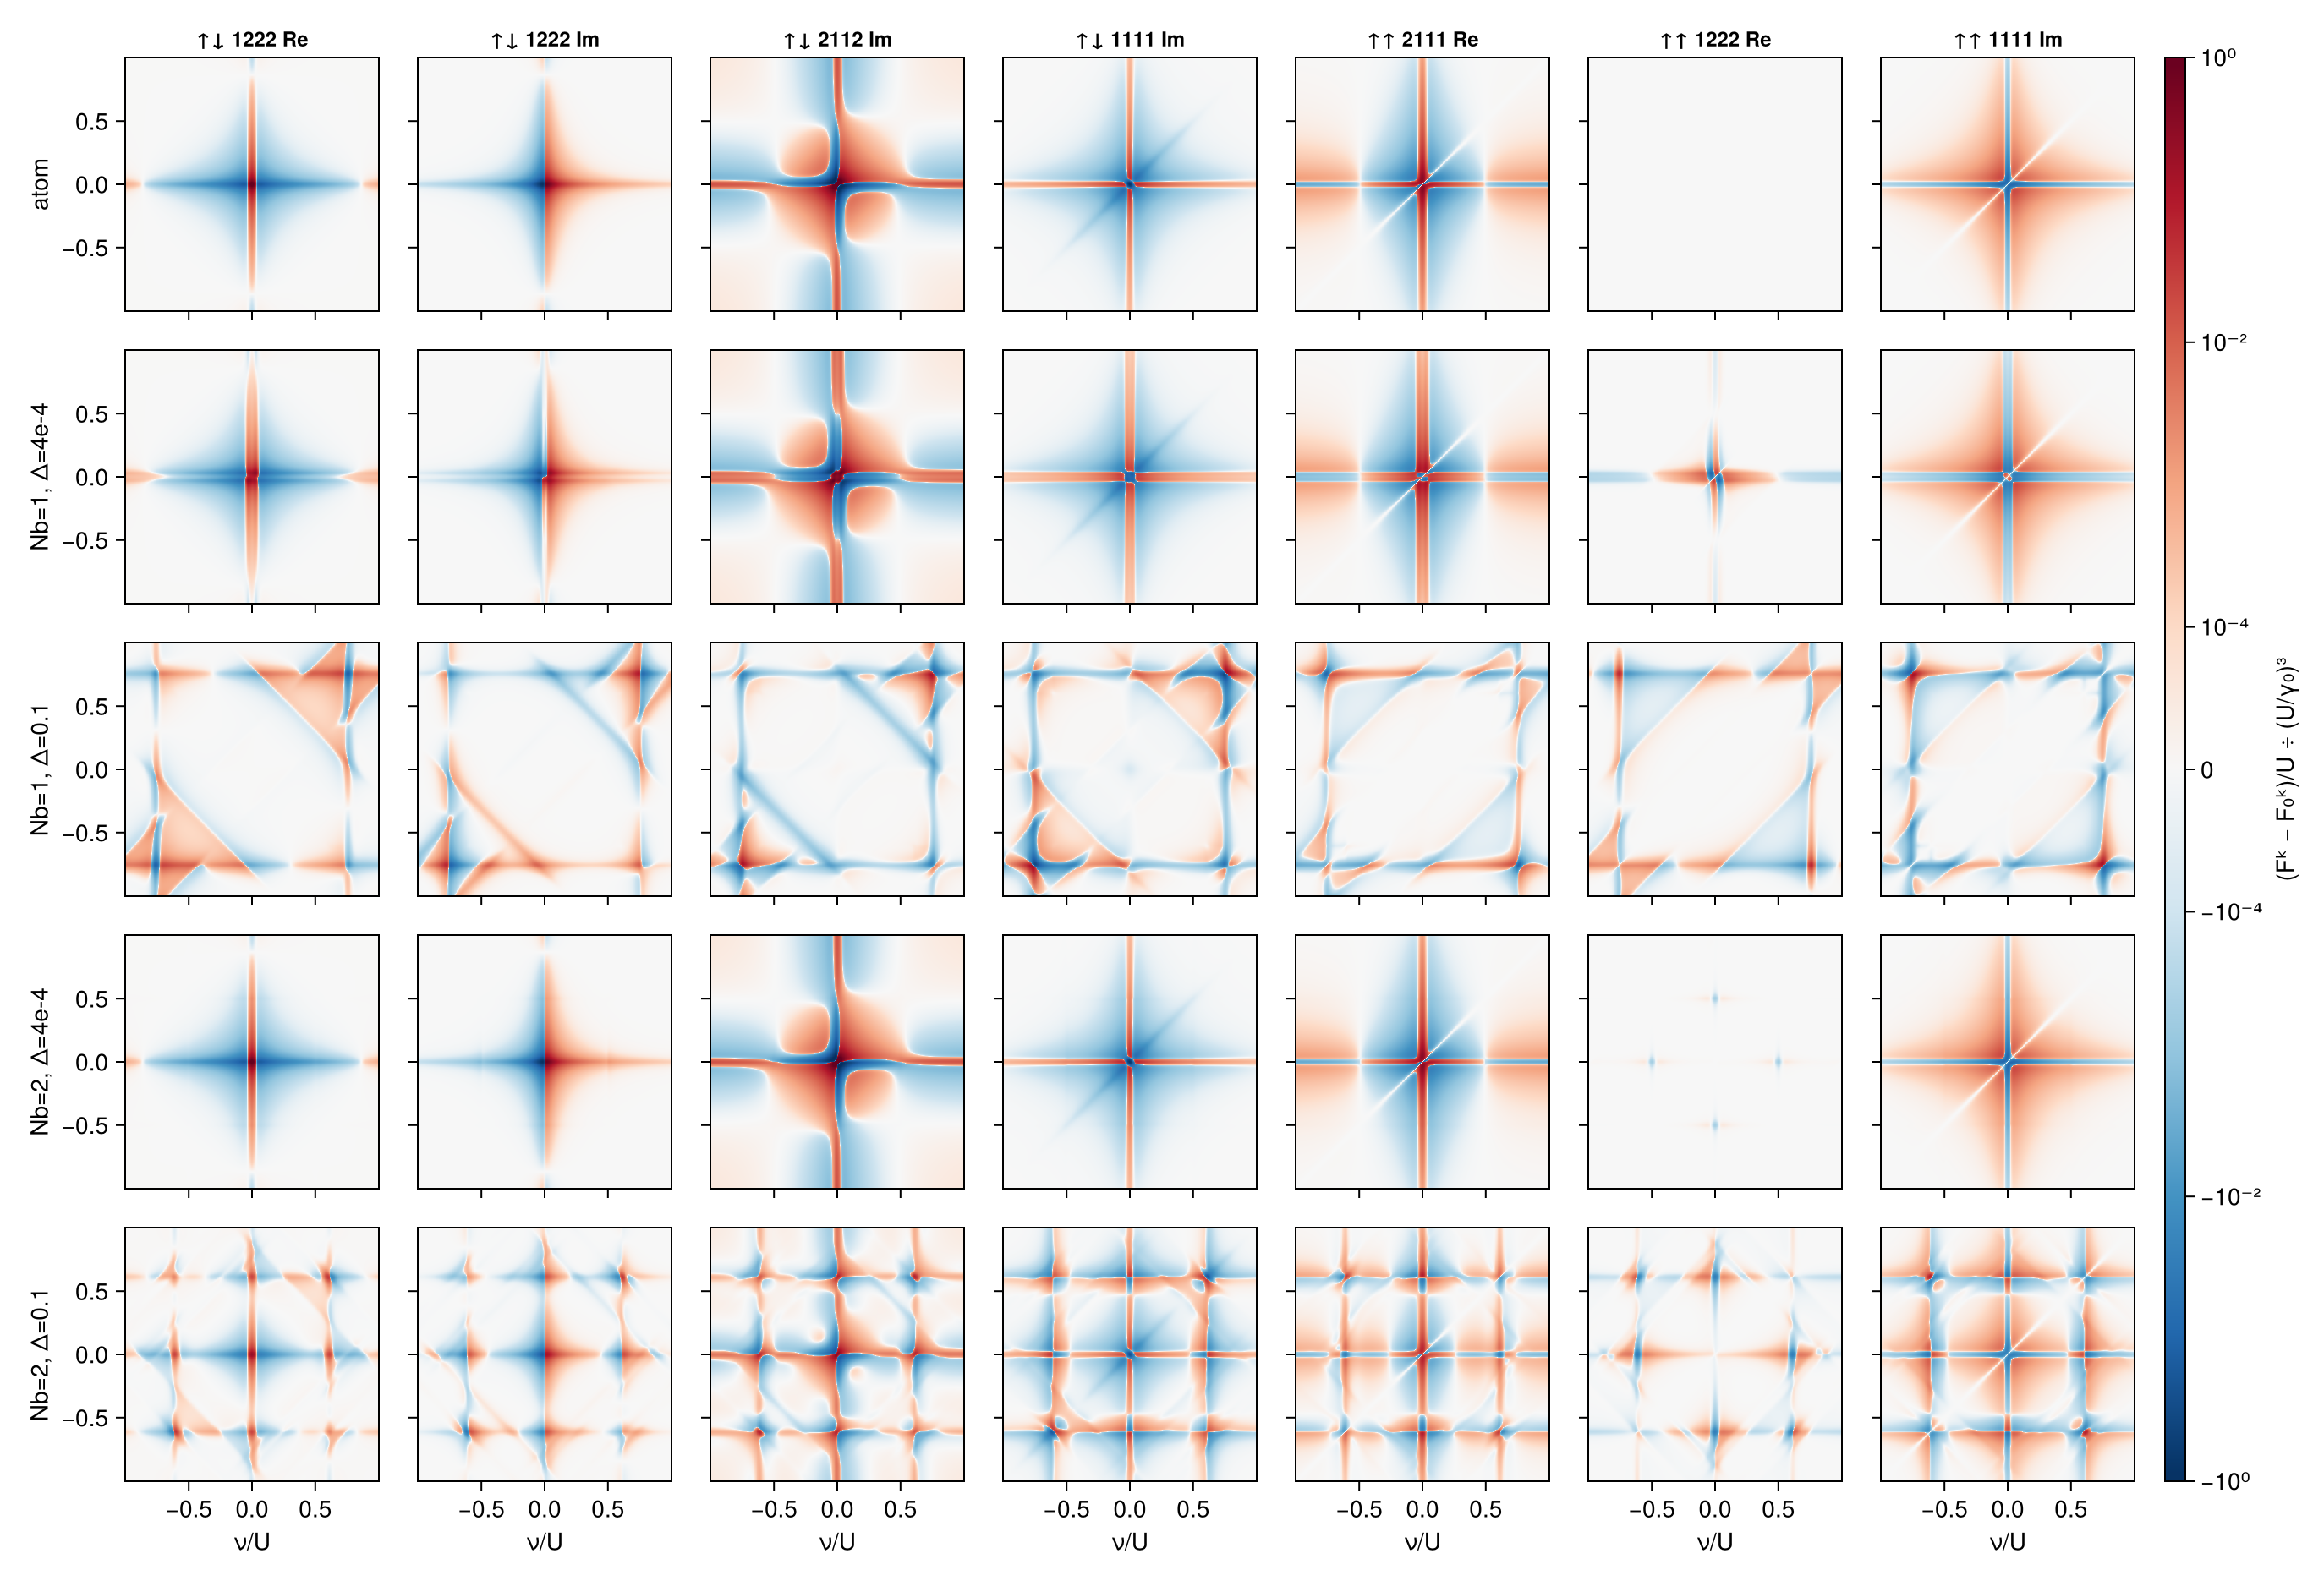

In [18]:
normkf = (HU / HT)^3
panels = [((1,2,2,2), real, :updn, "↑↓ 1222 Re"), ((1,2,2,2), imag, :updn, "↑↓ 1222 Im"), ((2,1,1,2), imag, :updn, "↑↓ 2112 Im"),
          ((1,1,1,1), imag, :updn, "↑↓ 1111 Im"), ((2,1,1,1), real, :upup, "↑↑ 2111 Re"), ((1,2,2,2), real, :upup, "↑↑ 1222 Re"),
          ((1,1,1,1), imag, :upup, "↑↑ 1111 Im")]
tkf = @elapsed for (lab, m) in cases, s in (:updn, :upup)
    key = m isa AIMModel ? (nbath(m), (lab == "Nb=$(nbath(m)), Δ=0.1") ? 0.1 : 4e-4, s) : (0, 0.0, s)
    haskey(KFstore, key) || (KFstore[key] = vertex_grid(νkf, νkf, 0.0, hprm, heatmap_tables(m, s, :KF)))
end
@printf("KF slices for O3: %.0f s\n", tkf)
keyof(lab, m, s) = m isa AIMModel ? (nbath(m), (lab == "Nb=$(nbath(m)), Δ=0.1") ? 0.1 : 4e-4, s) : (0, 0.0, s)
fig = Figure(size = (1500, 1100))
for (r, (lab, m)) in enumerate(cases), (c, (k, part, s, title)) in enumerate(panels)
    F = KFstore[keyof(lab, m, s)]
    X = part.((F[k..., :, :] .- bare_vertex_kf(k, HU, s === :updn)) ./ HU ./ normkf)
    ax = Axis(fig[r, c]; title = r == 1 ? title : "", titlesize = 12, aspect = 1, width = 150, height = 150,
              ylabel = c == 1 ? lab : "", xlabel = r == length(cases) ? "ν/U" : "", xticks = -0.5:0.5:0.5, yticks = -0.5:0.5:0.5)
    heatmap!(ax, νkf, νkf, symlog.(X, 1e-4); colormap = RDBU, colorrange = (-1, 1), rasterize = 2)
    c > 1 && hideydecorations!(ax; grid = false, ticks = false, label = true)
    r < length(cases) && hidexdecorations!(ax; grid = false, ticks = false)
end
Colorbar(fig[1:length(cases), length(panels) + 1]; colormap = RDBU, limits = (-1, 1), ticks = symlog_ticks(1e-4, 0:-2:-4),
         label = "(Fᵏ − F₀ᵏ)/U ÷ (U/γ₀)³")
resize_to_layout!(fig)
save(joinpath(FIGDIR, "o3_p2_kf.png"), fig; px_per_unit = 2); save(joinpath(FIGDIR, "o3_p2_kf.pdf"), fig)
fig

**Reading O3.** The MF maxima printed above put numbers on what the colours show.

*MF (P1).*
* $N_b=1$ with the moment effectively free ($\beta\Delta_{\rm ST}=0.10$): the atom's pattern, with the cross at $\nu^{(\prime)}=\pm\pi T$ from the
  $\beta\delta_\omega$ terms of Eq. (85), at about half the atom's amplitude (0.48 vs 0.95).
* $N_b=1$ with the moment screened ($\beta\Delta_{\rm ST}=15.7$): the panel is blank, because the whole vertex is $2\times10^{-5}$ of the
  atom's, below the colour threshold. This is O2's cut-off, seen on the entire plane.
* $N_b=2$: at weak coupling it is indistinguishable from the atom (0.94). At $\Delta=0.1$ the cross survives at a tenth
  of the amplitude (0.098). The Kramers doublet is never screened (O1), so the $\beta\delta_\omega$ terms cannot be cut off.

*KF (P2).*
* The weakly coupled rows reproduce the atom's panels. Trap 1 is visible directly: the ↑↑ 1222 column, $F^{[1]}_{\uparrow\uparrow}$, is
  identically zero for the atom and nonzero for every AIM row.
* The screened $N_b=1$ row loses the atom's cross at the origin, where the atom has its $\gamma_0$-limited spikes. What
  remains is structure along lines near $|\nu|,|\nu'|\approx0.75$, on the scale of the many-body excitation energies.
* $N_b=2$ at $\Delta=0.1$ keeps the central cross (unscreened doublet), with replicas along $|\nu|,|\nu'|\approx0.6$, near the bath
  energies $\pm D/2$ shifted by the hybridisation.

These readings are visual, not benchmarks.

## Summary

| Item | Result |
|:--|:--|
| Sec. 1 | sum rule exact, $\varepsilon_n$ symmetric, anticommutators of all $2(N_b+1)$ modes, $\langle n_{d\sigma}\rangle=\frac12$ at every $T$ |
| I1 | chain walk = dense PSF for atom, dimer, $N_b=1,2$ (24 permutations, `:full`/`:connected`); $N_b=3$ feasible |
| I2 | Dict merge = pairwise merge, same order; straddled cells re-joined |
| I3 | `ImpurityModel`; existing suite unchanged |
| A1–A3 | closed forms ≤ 1e-13; the 12 reference values ≤ 4e-14; $U=0$: MF ≤ 4e-14, KF ≤ 4e-11 (values up to $1/\gamma_0$) |
| B1 | $S^{\rm con}\le2\times10^{-15}$, $F\equiv0$ |
| B2 | exact at $V=0$, $\propto V^2$; eigenvector mixing breaks it at $V=10^{-4}$ for $N_b=2$ unless `otol` ≥ 1e-8 |
| B3 | Eq. (84) with the discrete-bath $\chi_0$ to 1.3e-5 on brackets of order 1–2 |
| B4, B5 | crossing ≤ 4e-13; $G^{1111}=0$, $F^{2222}\equiv0$, $F^{[\eta]}$ = regular sums ≤ 7e-13; $F^{[\eta]}_{\uparrow\uparrow}\ne0$ |
| B6 | see the B6 cell |
| O1 | table reproduced; screening only for odd $N_b$ |
| O2 | cut-off at the doublet gap $a-b$, with a sign change near $\beta\Delta_{\rm ST}\approx25$ |